In [2]:
%pip install -q numpy pandas openpyxl scikit-learn matplotlib ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from ucimlrepo import fetch_ucirepo

Note: you may need to restart the kernel to use updated packages.


In [3]:
# DATA ACQUISITION

# fetch dataset 
obesity_data = fetch_ucirepo(id=544) 
  
# data (as pandas dataframes) 
X = obesity_data.data.features 
y = obesity_data.data.targets 
  
# metadata 
print(obesity_data.metadata) 
  
# variable information 
print(obesity_data.variables) 

# Convert to numpy arrays and prepare data
# Select relevant features: Gender, Age, Height
df = pd.concat([X, y], axis=1)
print("\nDataset preview:")
print(df.head())

# Encode Gender (Male=1, Female=0)
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

# Feature matrix X and target vector y
X = df[["Gender", "Age", "Height"]].values
y = df["Weight"].values.reshape(-1, 1)

print("\nDimensions BEFORE normalization:")
print("X shape:", X.shape)   # (m, n)
print("y shape:", y.shape)   # (m, 1)

{'uci_id': 544, 'name': 'Estimation of Obesity Levels Based On Eating Habits and Physical Condition ', 'repository_url': 'https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition', 'data_url': 'https://archive.ics.uci.edu/static/public/544/data.csv', 'abstract': 'This dataset include data for the estimation of obesity levels in individuals from the countries of Mexico, Peru and Colombia, based on their eating habits and physical condition. ', 'area': 'Health and Medicine', 'tasks': ['Classification', 'Regression', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 2111, 'num_features': 16, 'feature_types': ['Integer'], 'demographics': ['Gender', 'Age'], 'target_col': ['NObeyesdad'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2019, 'last_updated': 'Tue Sep 10 2024', 'dataset_doi': '10.24432/C5H31Z', 'creators': [], 'intro_paper': {'ID': 358, 'type': 

Data Acquisition:
For my data, I loaded the "Estimation of Obesity Levels Based On Eating Habits and Physical Condition" dataset from the UCI Machine learning repository. I used the continuous variables Gender, Age, and Height as the input features and Weight as the target variable that the model is trying to predict. I converted the Gender column into numerical values so it could be used in mathematical operations. After setting up the matrix X and target vector y, I printed their shapes to make sure the number of rows matched and that the matrix dimensions were compatible for linear regression. This step is important because linear regression relies on matrix multiplication, hewre incorrect dimensions would cause errors or incorrect results. Verifying the data structure helps prevent mistakes later on.


After loading the dataset and selecting the features, my feature matrix X has dimensions m by 3, where m represents the total number of samples in the dataset and 3 represents the number of input features, which are Gender, Age, and Height. The target vector y has dimensions m by 1, where m again represents the number of samples and the single column contains the corresponding Weight values. X and y must have compatible dimensions because linear regression relies on matrix multiplication to generate predictions. When X is multiplied by the parameter vector, the result must produce one predicted value per sample so it can be directly compared to y. If the number of rows in X and y do not match, the model would not be able to correctly align each prediction with its true target value, which would make both training and error calculation invalid.

In [4]:
# NORMALIZATION

X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

print("\nFeature means BEFORE normalization:", X_mean)
print("Feature std BEFORE normalization:", X_std)

X_norm = (X - X_mean) / X_std

print("\nFeature means AFTER normalization:", X_norm.mean(axis=0))
print("Feature std AFTER normalization:", X_norm.std(axis=0))

# Add bias column
m = X_norm.shape[0]
X_bias = np.hstack([np.ones((m, 1)), X_norm])

print("\nX with bias shape:", X_bias.shape)


Feature means BEFORE normalization: [ 0.50592136 24.31259991  1.70167735]
Feature std BEFORE normalization: [0.49996494 6.34446502 0.09328272]

Feature means AFTER normalization: [-5.38544944e-17  0.00000000e+00 -5.38544944e-16]
Feature std AFTER normalization: [1. 1. 1.]

X with bias shape: (2111, 4)


After loading the data, I applied z score normalization by subtracting the mean and dividing by the standard deviation for each feature so that all features are on a standardized scale (ap stat reference). This step is necessary because the original features have very different ranges, such as height being close to one and age being much larger. If the data is not normalized, gradient descent can converge very slowly or become unstable because some features dominate the update steps. I printed the means and standard deviations before and after normalization to confirm that the transformed features are centered around zero (all ended up really small (e-17, 0, -16 respectively)) with a standard deviation close to one. This verification step shows that the normalization was applied correctly.


Theta shape: (4, 1)


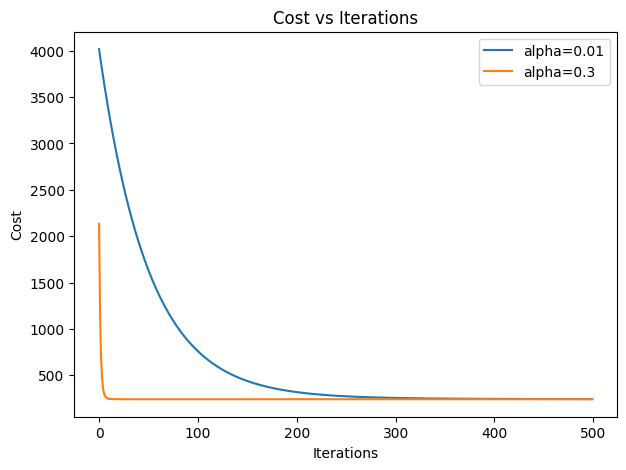

In [5]:
# GRADIENT DESCENT

def compute_cost(X, y, theta):
    m = len(y)
    error = X @ theta - y
    return (1/(2*m)) * (error.T @ error)


def gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = []

    for i in range(iterations):
        gradient = (1/m) * X.T @ (X @ theta - y)
        theta = theta - alpha * gradient
        cost_history.append(compute_cost(X, y, theta)[0][0])

    return theta, cost_history


# Initialize parameters
n = X_bias.shape[1]
theta_init = np.zeros((n, 1))

print("\nTheta shape:", theta_init.shape)


# Train with two learning rates
alpha1 = 0.01
alpha2 = 0.3
iterations = 500

theta_1, cost_1 = gradient_descent(X_bias, y, theta_init, alpha1, iterations)
theta_2, cost_2 = gradient_descent(X_bias, y, theta_init, alpha2, iterations)

# Plot cost vs iterations
plt.figure(figsize=(7,5))
plt.plot(cost_1, label="alpha=0.01")
plt.plot(cost_2, label="alpha=0.3")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.legend()
plt.show()

In this part, I implemented gradient descent to train the linear regression model. I first defind the cost function to measure how far the model’s predictions are from the actual target values and then computed the gradient using matrix operations. This vectorized approach allows the process of the entire dataset at once, which is more efficient and closer to how real machine learning libraries work (this might be a stretch). I initialized the parameter values and updated them iteratively using different learning rates. The plot of the cost versus the number of iterations visualize how the model learns over time. This matters because it helps show if the model is converging properly and how the choice of learning rate affects training behavior.

Both the cost function and gradient formulas are vectorized because they operate on the entire dataset at once instead of processing one data point at a time. This makes the computation much faster and more efficient, especially for large datasets, since matrix operations are optimizes better. Vectorization also keeps the implementation mathematically clean and closer to the linear algebra aproach of linear regression. If the feature matrix X has dimensions m by n, then the gradient must have dimensions n by 1 so that it matches the shape of the parameter vector and can be used directly to update the model weights. This dimensional consistency is necessary for gradient descent to work correctly. When plotting the cost versus iteration using two different learning rates, we can tell that a reasonable learning rate produces a smooth decrease in cost over time, while a learning rate that is too large causes the cost to oscillate or even increase instead of converging. This happens because large update steps overshoot the minimum of the cost function, preventing the algorithm from stabilizing.

In [6]:
# NUMERICAL GRADIENT CHECK

epsilon = 1e-5
theta_test = theta_init.copy()

analytical_grad = (1/m) * X_bias.T @ (X_bias @ theta_test - y)

numerical_grad = np.zeros_like(theta_test)

for i in range(len(theta_test)):
    theta_plus = theta_test.copy()
    theta_minus = theta_test.copy()

    theta_plus[i][0] += epsilon
    theta_minus[i][0] -= epsilon

    cost_plus = compute_cost(X_bias, y, theta_plus)
    cost_minus = compute_cost(X_bias, y, theta_minus)

    numerical_grad[i] = (cost_plus - cost_minus) / (2 * epsilon)

print("\nAnalytical Gradient (first 5 values):")
print(analytical_grad[:5])

print("\nNumerical Gradient (first 5 values):")
print(numerical_grad[:5])

print("\nGradient difference norm:")
print(np.linalg.norm(analytical_grad - numerical_grad))


Analytical Gradient (first 5 values):
[[-86.58605813]
 [ -4.2332602 ]
 [ -5.30402973]
 [-12.12720417]]

Numerical Gradient (first 5 values):
[[-86.58605807]
 [ -4.23326019]
 [ -5.30402976]
 [-12.12720417]]

Gradient difference norm:
6.691900403885995e-08


The numerical gradeint check estimates the gradient by slightly increasing and decreasing each parameter and measuring how much the cost changes. I then compared this numerical result with the analytical gradient calculated by my vectorized formula. Since the values were extremely close, this confirmed that my gradient calculation was correct. This step is important because small mistakes in gradient formulas can still produce results that look reasonable but are mathematically worng. By verifying both methods match, I can be confident that the optimization process is implemented properly.

In [7]:
# MODEL COMPARISON

# a. Normal Equation

theta_normal = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y

# b. Scikit-learn

X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.2, random_state=42
)

sk_model = LinearRegression()
sk_model.fit(X_train, y_train)

# Predictions
X_train_bias = np.hstack([np.ones((X_train.shape[0],1)), X_train])
X_test_bias = np.hstack([np.ones((X_test.shape[0],1)), X_test])

y_train_pred_gd = X_train_bias @ theta_1
y_test_pred_gd = X_test_bias @ theta_1

y_train_pred_sk = sk_model.predict(X_train)
y_test_pred_sk = sk_model.predict(X_test)

All three methods aim to minimize the same error function, but they use different strategies to find the optimal parameters. Gradient descent uses updates through every iteration, the normal equation uses a direct matrix solution, and scikit learn uses an optimized library implementation (to my understanding). Comparing these methods is important because similar results across all three indicate that the model and math are working correctly. It also shows how different approaches can solve the same problem in practice.
... shown below

In [8]:
# EVALUATION

print("\n--- GRADIENT DESCENT MODEL ---")

print("Train MSE:", mean_squared_error(y_train, y_train_pred_gd))
print("Test MSE:", mean_squared_error(y_test, y_test_pred_gd))

print("Train R2:", r2_score(y_train, y_train_pred_gd))
print("Test R2:", r2_score(y_test, y_test_pred_gd))


print("\n--- SCIKIT-LEARN MODEL ---")

print("Train MSE:", mean_squared_error(y_train, y_train_pred_sk))
print("Test MSE:", mean_squared_error(y_test, y_test_pred_sk))

print("Train R2:", r2_score(y_train, y_train_pred_sk))
print("Test R2:", r2_score(y_test, y_test_pred_sk))


--- GRADIENT DESCENT MODEL ---
Train MSE: 484.9170469281554
Test MSE: 500.3978278915708
Train R2: 0.28769919881648465
Test R2: 0.2903275149935839

--- SCIKIT-LEARN MODEL ---
Train MSE: 482.57231216316234
Test MSE: 497.6934952470634
Train R2: 0.29114340945467
Test R2: 0.2941628443278419


This allows the model to be trained on one portion of the data and evaluated on unseen data. I calculated mean squared error and R squared for both sets to measure prediction accuracy and how well the model explains the variance in the data. This step is important because good performance on training data alone does not guarantee good real world performance. By comparing training and testing metrics, I can check whether the model generalizes well or is overfitting to the training data.

In the results, the training and testing metrics are relatively close, which suggests that the model is not severely overfitting. If the training error were much lower than the testing error, it would indicate that the model is memorizing the training data instead of learning general patterns. Since the performance remains consistent across both sets, the model appears to generalize reasonably well.

In [9]:
# PARAMETER COMPARISON

print("\nGradient Descent Theta:")
print(theta_1)

print("\nNormal Equation Theta:")
print(theta_normal)

print("\nScikit-learn Intercept + Coefs:")
print("Intercept:", sk_model.intercept_)
print("Coefficients:", sk_model.coef_)


Gradient Descent Theta:
[[86.0171459 ]
 [-4.22407276]
 [ 5.77305693]
 [14.25125247]]

Normal Equation Theta:
[[86.58605813]
 [-5.91736682]
 [ 6.00424012]
 [15.94275498]]

Scikit-learn Intercept + Coefs:
Intercept: [86.49255639]
Coefficients: [[-5.93619822  5.75000667 15.83141821]]


This compares the learned parameter values from gradient descent, the normal equation, and scikit learn. Even though the methods use different techniques, the resulting parameters should be very similar because they are all optimizing the same objective. Printing and comparing these values helps confirm that my manual implementation is consistent with standard machine learning tools. Thsi step is important because it validates the correctness of the custom algorithm and demonstrates that the mathematical theory of linear regression produces consitent results across different solution methods.